Q1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def motion_blur(image, size=15):
    kernel = np.zeros((size, size))
    kernel[int((size - 1)/2), :] = np.ones(size)
    kernel /= size
    return cv2.filter2D(image, -1, kernel), kernel

In [3]:
def inverse_filtering(degraded, H):
    # DFT of degraded image
    G = np.fft.fft2(degraded)
    H_f = np.fft.fft2(H, s=degraded.shape)

    # Avoid divide by zero (add epsilon)
    epsilon = 1e-6
    F_hat = G / (H_f + epsilon)

    # Inverse DFT to get restored image
    f_restored = np.fft.ifft2(F_hat)
    f_restored = np.abs(f_restored)
    return np.uint8(np.clip(f_restored, 0, 255))

In [5]:
# Load grayscale image
img = cv2.imread("bullet-space.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

# Apply motion blur (degradation)
degraded, kernel = motion_blur(img, size=15)

# Restore using inverse filtering
restored = inverse_filtering(degraded, kernel)



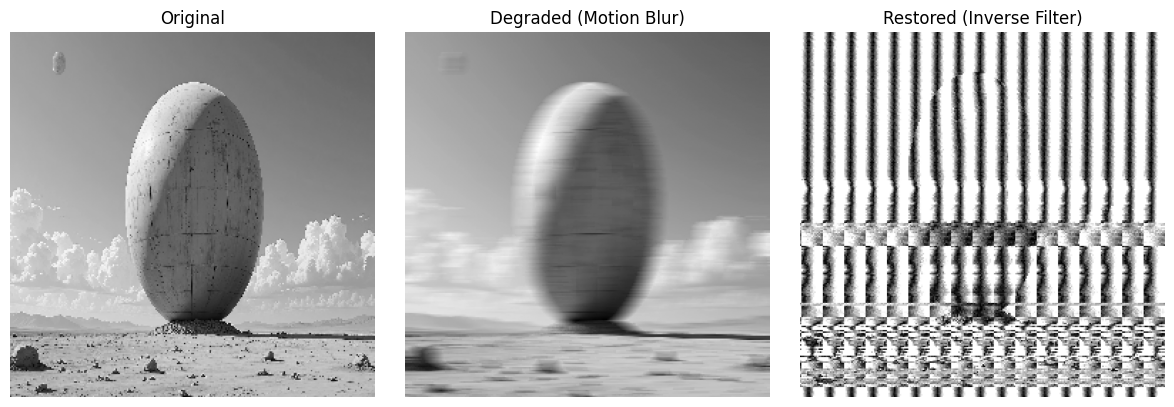

In [7]:
titles = ["Original", "Degraded (Motion Blur)", "Restored (Inverse Filter)"]
images = [img, degraded, restored]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Q2

In [8]:
img = cv2.imread("bullet-space.jpg", cv2.IMREAD_GRAYSCALE)

In [9]:
def motion_blur_psf(shape, a=0.1, b=0.1, T=1):
    M, N = shape
    U, V = np.meshgrid(np.arange(-N//2, N//2), np.arange(-M//2, M//2))
    H = T * (np.sinc(a*U + b*V) + 1e-8) * np.exp(-1j*np.pi*(a*U + b*V))
    return np.fft.ifftshift(H)

H = motion_blur_psf(img.shape)

In [10]:
F = np.fft.fft2(img)

# Apply degradation
G = H * F

# Add Gaussian noise
noise = np.random.normal(0, 10, img.shape)
G_noisy = G + np.fft.fft2(noise)

# Degraded image
g = np.abs(np.fft.ifft2(G_noisy))

In [11]:
K = 0.01  # constant ratio
H_conj = np.conj(H)
W_filter_const = (H_conj / (np.abs(H)**2 + K))
F_hat_const = W_filter_const * G_noisy
f_hat_const = np.abs(np.fft.ifft2(F_hat_const))

In [12]:
S_gg = np.abs(G_noisy)**2
# Noise power spectrum (estimated from added noise)
S_nn = np.abs(np.fft.fft2(noise))**2

# Wiener filter using auto-correlation
W_filter_auto = (H_conj / (np.abs(H)**2 + (S_nn / (S_gg + 1e-8))))
F_hat_auto = W_filter_auto * G_noisy
f_hat_auto = np.abs(np.fft.ifft2(F_hat_auto))

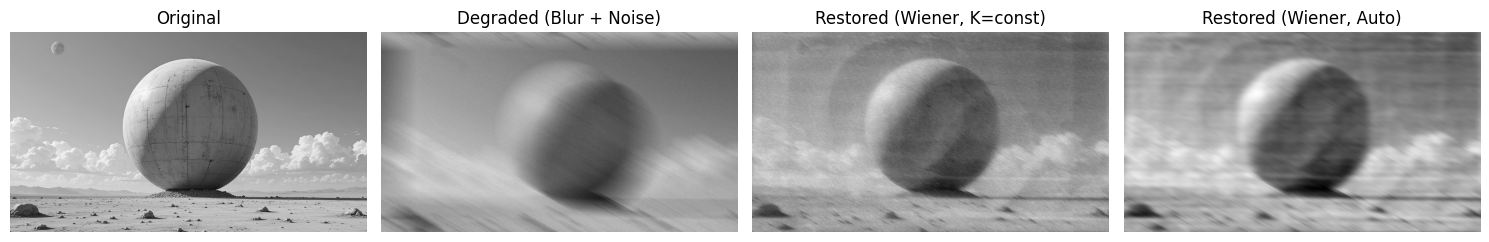

In [13]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(g, cmap='gray')
plt.title("Degraded (Blur + Noise)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(f_hat_const, cmap='gray')
plt.title("Restored (Wiener, K=const)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(f_hat_auto, cmap='gray')
plt.title("Restored (Wiener, Auto)")
plt.axis("off")

plt.tight_layout()
plt.show()

Q3

In [15]:
def rgb_to_hsi(img):
    # Normalize RGB values to [0,1]
    img = img.astype(np.float32) / 255.0
    R, G, B = img[:, :, 2], img[:, :, 1], img[:, :, 0]

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_val = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 / (R + G + B + 1e-8)) * min_val  # avoid division by zero

    # Hue calculation
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G) ** 2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(num / den)

    H = np.zeros_like(R)
    H[B <= G] = theta[B <= G]
    H[B > G] = (2 * np.pi - theta[B > G])

    H = H / (2 * np.pi)  # Normalize to [0,1]

    return H, S, I

In [16]:
img = cv2.imread("bullet-space.jpg")  #

In [17]:
H, S, I = rgb_to_hsi(img)

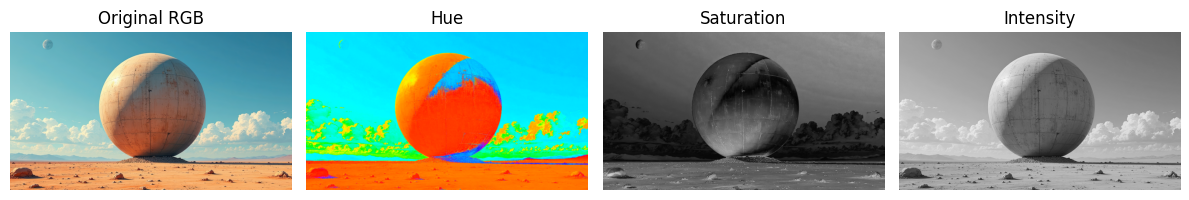

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(H, cmap="hsv")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(I, cmap="gray")
plt.title("Intensity")
plt.axis("off")

plt.tight_layout()
plt.show()